In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report
import warnings
warnings.filterwarnings('ignore')

In [2]:
titanic_data=sns.load_dataset("titanic")

In [3]:
titanic_data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [4]:
X=titanic_data[['pclass','sex','age','sibsp','parch','fare']]
y=titanic_data['survived']
X['sex']=X['sex'].map({'female':0,'male':1})
X['age'].fillna(X['age'].median(),inplace=True)

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
rf_classifier=RandomForestClassifier(n_estimators=100,random_state=42)
rf_classifier.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [7]:
y_pred=rf_classifier.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
Classification_rep=classification_report(y_test,y_pred)
print(f"accuracy",accuracy*100)

accuracy 79.88826815642457


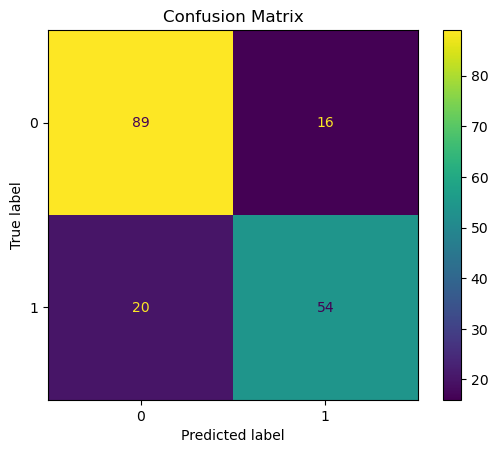

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

In [9]:
print("""
This confusion matrix shows the model's prediction performance.
- Correct predictions are shown on the diagonal.
- Higher values on the diagonal indicate good model accuracy.
- Off-diagonal values represent misclassifications.
- The model performs reasonably well but has some errors in predicting survival.
""")


This confusion matrix shows the model's prediction performance.
- Correct predictions are shown on the diagonal.
- Higher values on the diagonal indicate good model accuracy.
- Off-diagonal values represent misclassifications.
- The model performs reasonably well but has some errors in predicting survival.



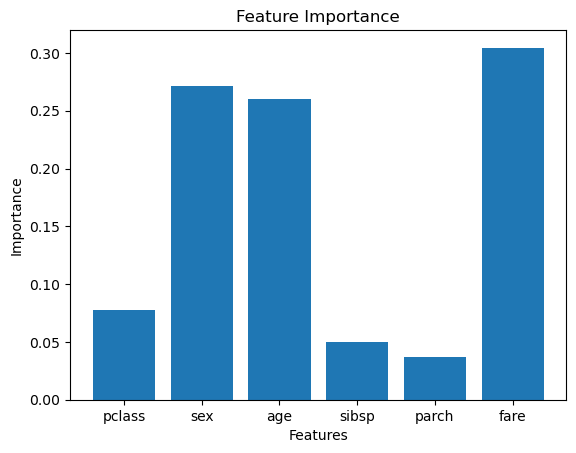

In [10]:
feature_importance = rf_classifier.feature_importances_
features = X.columns

plt.bar(features, feature_importance)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [11]:
print("""
This graph shows how important each feature is in predicting survival.
- Features with higher values have more impact on predictions.
- Typically, 'sex' and 'fare' are strong predictors in the Titanic dataset.
- This helps us understand which factors influence survival the most.
""")


This graph shows how important each feature is in predicting survival.
- Features with higher values have more impact on predictions.
- Typically, 'sex' and 'fare' are strong predictors in the Titanic dataset.
- This helps us understand which factors influence survival the most.

